Dataset shape: (45716, 10)
       name   id nametype     recclass  mass (g)  fall    year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
2      Abee    6    Valid          EH4  107000.0  Fell  1952.0  54.21667   
3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976.0  16.88333   
4   Achiras  370    Valid           L6     780.0  Fell  1902.0 -33.16667   

     reclong           GeoLocation  
0    6.08333     (50.775, 6.08333)  
1   10.23333  (56.18333, 10.23333)  
2 -113.00000    (54.21667, -113.0)  
3  -99.90000     (16.88333, -99.9)  
4  -64.95000   (-33.16667, -64.95)  

Cleaned dataset shape: (45093, 10)
Year range: 1851.0 to 2013.0


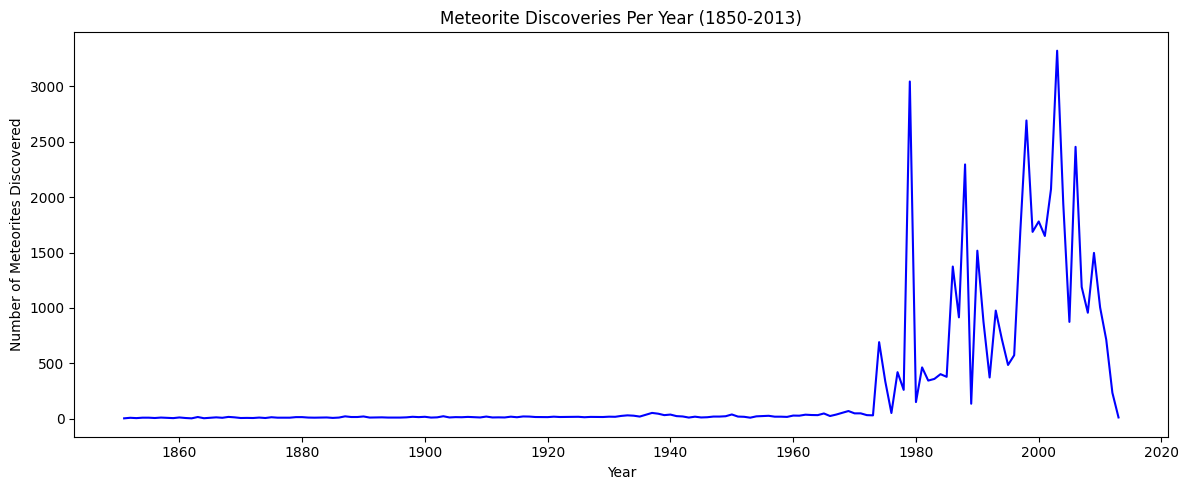

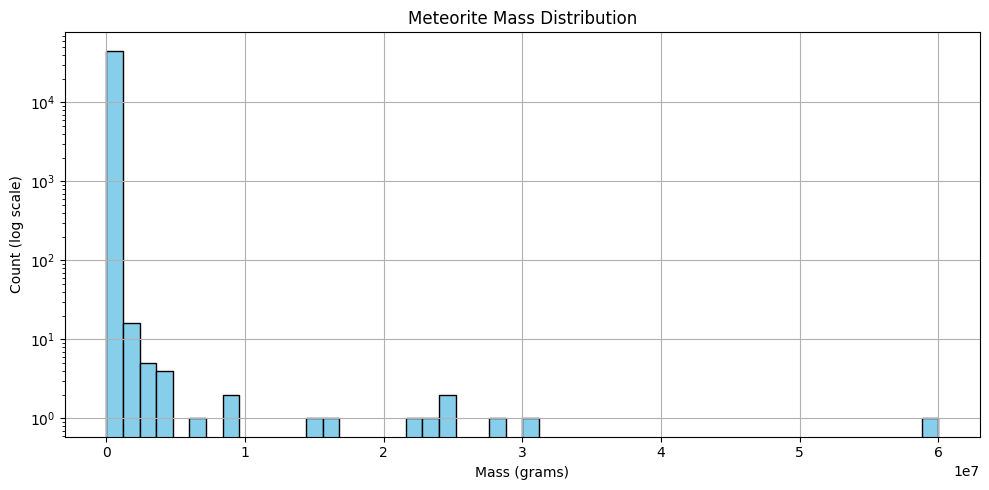


=== Mass Statistics ===
count       45093.00
mean         9607.38
std        430448.61
min             0.00
25%             7.10
50%            31.75
75%           195.56
max      60000000.00
Name: mass (g), dtype: float64


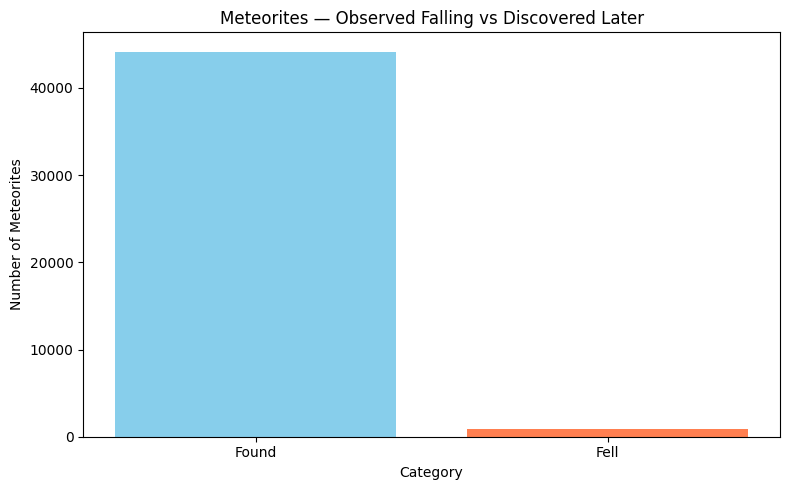


=== Fell vs Found ===
fall
Found    44170
Fell       923
Name: count, dtype: int64

Only 2.0% of meteorites were observed falling


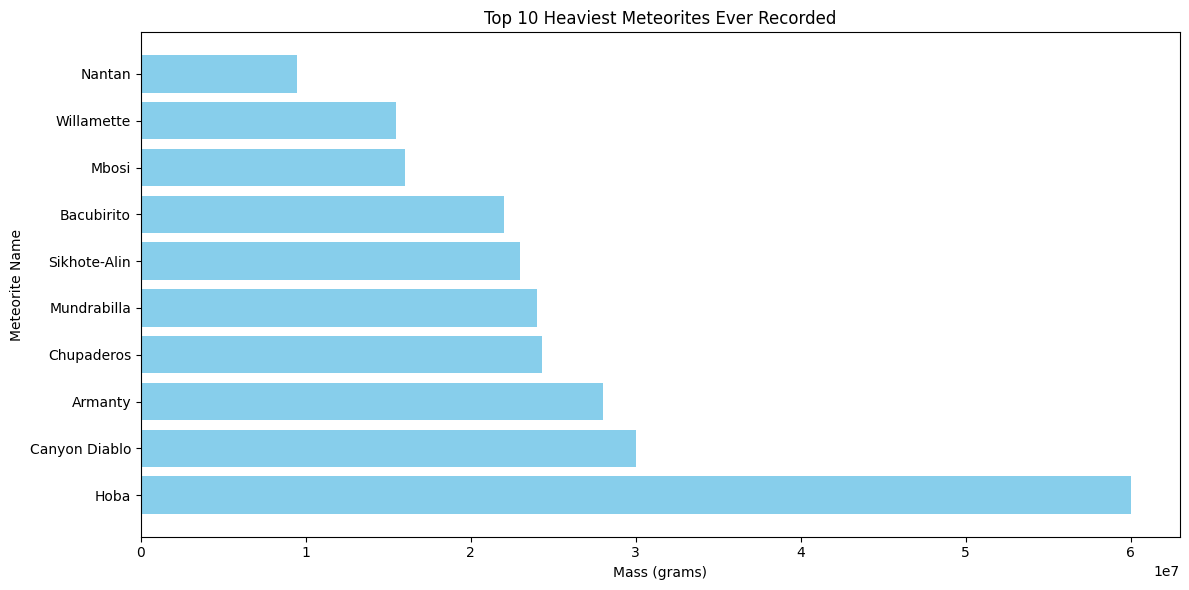

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



=== Top 10 Heaviest Meteorites ===
                name    mass (g)    year
16392           Hoba  60000000.0  1920.0
5370   Canyon Diablo  30000000.0  1891.0
3455         Armanty  28000000.0  1898.0
5468      Chupaderos  24300000.0  1852.0
26297    Mundrabilla  24000000.0  1911.0
920     Sikhote-Alin  23000000.0  1947.0
5016      Bacubirito  22000000.0  1863.0
22921          Mbosi  16000000.0  1930.0
38317     Willamette  15500000.0  1902.0
26338         Nantan   9500000.0  1958.0


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


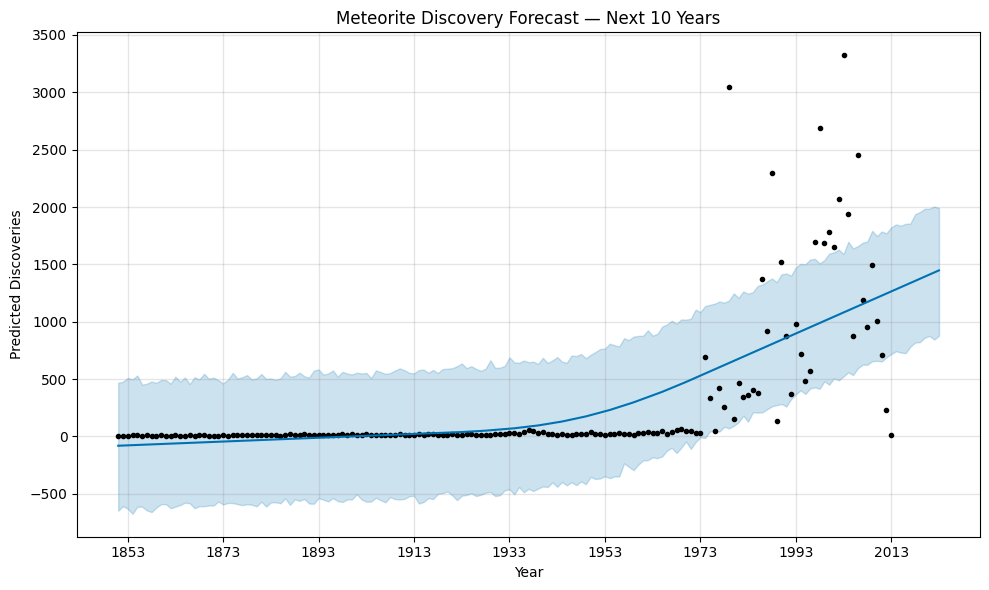


=== Key Insights ===
Total meteorites analyzed: 45,093
Peak discovery year: 2003 with 3323 meteorites
Average mass: 9607.38 grams
Heaviest meteorite: Hoba at 60,000,000 grams
Observed falling: 923 (2.0%)
Discovered later: 44170 (98.0%)


In [8]:
# ============================================================
# NASA METEORITE LANDINGS ANALYSIS + PROPHET FORECASTING
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# ── 2. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv("/content/Meteorite_Landings.csv")
print(f"Dataset shape: {df.shape}")
print(df.head())

# ── 3. DATA CLEANING ─────────────────────────────────────────
# Drop rows with missing year or mass
df = df.dropna(subset=['year', 'mass (g)'])

# Filter to reliable historical range
df = df[(df['year'] > 1850) & (df['year'] < 2014)]

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

# ── 4. YEARLY DISCOVERY TREND ────────────────────────────────
yearly = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly.values, color='blue')
plt.xlabel('Year')
plt.ylabel('Number of Meteorites Discovered')
plt.title('Meteorite Discoveries Per Year (1850-2013)')
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150)
plt.show()

# ── 5. MASS DISTRIBUTION ─────────────────────────────────────
# Log scale needed — mass ranges from grams to tons
plt.figure(figsize=(10, 5))
df['mass (g)'].hist(bins=50, log=True, edgecolor='black', color='skyblue')
plt.xlabel('Mass (grams)')
plt.ylabel('Count (log scale)')
plt.title('Meteorite Mass Distribution')
plt.tight_layout()
plt.savefig('mass_distribution.png', dpi=150)
plt.show()

print(f"\n=== Mass Statistics ===")
print(df['mass (g)'].describe().round(2))

# ── 6. FELL VS FOUND ─────────────────────────────────────────
counts = df['fall'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=['skyblue', 'coral'])
plt.xlabel('Category')
plt.ylabel('Number of Meteorites')
plt.title('Meteorites — Observed Falling vs Discovered Later')
plt.tight_layout()
plt.savefig('fell_vs_found.png', dpi=150)
plt.show()

print(f"\n=== Fell vs Found ===")
print(counts)
print(f"\nOnly {counts['Fell']/counts.sum():.1%} of meteorites were observed falling")

# ── 7. TOP 10 HEAVIEST METEORITES ────────────────────────────
df_top10 = df.sort_values(by='mass (g)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(df_top10['name'], df_top10['mass (g)'], color='skyblue')
plt.xlabel('Mass (grams)')
plt.ylabel('Meteorite Name')
plt.title('Top 10 Heaviest Meteorites Ever Recorded')
plt.tight_layout()
plt.savefig('top10_heaviest.png', dpi=150)
plt.show()

print(f"\n=== Top 10 Heaviest Meteorites ===")
print(df_top10[['name', 'mass (g)', 'year']].to_string())

# ── 8. PROPHET TIME SERIES FORECAST ─────────────────────────
# Prepare data — Prophet requires ds and y columns
prophet_df = pd.DataFrame({
    'ds': pd.to_datetime(yearly.index.astype(int), format='%Y'),
    'y': yearly.values
})

# Train Prophet model
# Yearly seasonality disabled — data is annual not monthly
model = Prophet(yearly_seasonality=False)
model.fit(prophet_df)

# Forecast next 10 years
future = model.make_future_dataframe(periods=10, freq='Y')
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title('Meteorite Discovery Forecast — Next 10 Years')
plt.xlabel('Year')
plt.ylabel('Predicted Discoveries')
plt.tight_layout()
fig.savefig('forecast.png', dpi=150)
plt.show()

# ── 9. KEY INSIGHTS ──────────────────────────────────────────
print("\n=== Key Insights ===")
print(f"Total meteorites analyzed: {len(df):,}")
print(f"Peak discovery year: {yearly.idxmax():.0f} with {yearly.max():.0f} meteorites")
print(f"Average mass: {df['mass (g)'].mean():.2f} grams")
print(f"Heaviest meteorite: {df_top10.iloc[0]['name']} at {df_top10.iloc[0]['mass (g)']:,.0f} grams")
print(f"Observed falling: {counts['Fell']} ({counts['Fell']/counts.sum():.1%})")
print(f"Discovered later: {counts['Found']} ({counts['Found']/counts.sum():.1%})")